# CSIRO Competition Solution Notebook

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/resnet50/pytorch/default/1/resnet50-0676ba61.pth
/kaggle/input/csiro-biomass/sample_submission.csv
/kaggle/input/csiro-biomass/train.csv
/kaggle/input/csiro-biomass/test.csv
/kaggle/input/csiro-biomass/test/ID1001187975.jpg
/kaggle/input/csiro-biomass/train/ID2099464826.jpg
/kaggle/input/csiro-biomass/train/ID2037861084.jpg
/kaggle/input/csiro-biomass/train/ID1211362607.jpg
/kaggle/input/csiro-biomass/train/ID1853508321.jpg
/kaggle/input/csiro-biomass/train/ID193102215.jpg
/kaggle/input/csiro-biomass/train/ID698608346.jpg
/kaggle/input/csiro-biomass/train/ID1859251563.jpg
/kaggle/input/csiro-biomass/train/ID1880764911.jpg
/kaggle/input/csiro-biomass/train/ID853954911.jpg
/kaggle/input/csiro-biomass/train/ID1403107574.jpg
/kaggle/input/csiro-biomass/train/ID1781353117.jpg
/kaggle/input/csiro-biomass/train/ID384648061.jpg
/kaggle/input/csiro-biomass/train/ID1563418511.jpg
/kaggle/input/csiro-biomass/train/ID2125100696.jpg
/kaggle/input/csiro-biomass/train/ID482555369.jpg
/k

In [2]:
import shutil
import os

# Copy entire dataset folder
input_folder = "/kaggle/input/csiro-biomass"
output_folder = "/kaggle/working/csiro-biomass"

# Copy entire directory
shutil.copytree(input_folder, output_folder)

print(f"✓ Folder copied to: {output_folder}")

# Update paths
dataset_path = "/kaggle/working/csiro-biomass/train.csv"
print(f"dataset_path = '{dataset_path}'")

# List copied files
print(f"\nCopied files:")
for item in os.listdir(output_folder):
    item_path = os.path.join(output_folder, item)
    if os.path.isfile(item_path):
        size = os.path.getsize(item_path) / (1024 * 1024)
        print(f"  {item}: {size:.2f} MB")
    else:
        num_files = len(os.listdir(item_path))
        print(f"  {item}/: {num_files} files")

✓ Folder copied to: /kaggle/working/csiro-biomass
dataset_path = '/kaggle/working/csiro-biomass/train.csv'

Copied files:
  train.csv: 0.17 MB
  test/: 1 files
  train/: 357 files
  test.csv: 0.00 MB
  sample_submission.csv: 0.00 MB


In [3]:
import sys
sys.path.append("/kaggle/input/sam-optim")

In [4]:
import torch

torch.cuda.is_available()

True

In [5]:
from sam import *

# Data Cleaning

## Inconsistent Total & GDM calculation

In [6]:
import pandas as pd
import numpy as np

# Load, clean, and save
dataset_path = "/kaggle/working/csiro-biomass/train.csv"
output_path = dataset_path

df = pd.read_csv(dataset_path)
id_cols = ['image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']

# Pivot and check consistency
df_wide = df.pivot_table(index=id_cols, columns='target_name', values='target').reset_index()
df_wide['GDM_diff'] = abs(df_wide['GDM_g'] - (df_wide['Dry_Clover_g'] + df_wide['Dry_Green_g']))
df_wide['Total_diff'] = abs(df_wide['Dry_Total_g'] - (df_wide['Dry_Clover_g'] + df_wide['Dry_Green_g'] + df_wide['Dry_Dead_g']))

# Get bad images and remove
tolerance = 0.01
bad_images = df_wide[(df_wide['GDM_diff'] > tolerance) | (df_wide['Total_diff'] > tolerance)]['image_path'].unique()
df_clean = df[~df['image_path'].isin(bad_images)]

# Save and update path
df_clean.to_csv(output_path, index=False)
dataset_path = output_path

print(f"Removed {len(bad_images)} inconsistent images")
print(f"Cleaned data: {df_clean.shape[0]} rows, {df_clean['image_path'].nunique()} images")
print(f"Saved to: {dataset_path}")

Removed 1 inconsistent images
Cleaned data: 1780 rows, 356 images
Saved to: /kaggle/working/csiro-biomass/train.csv


# Data Augmentation & Transform

In [7]:
# Data Transform

from torchvision.transforms import v2
import torch

# to_tensor = v2.ToTensor()
# img_tensor = to_tensor(img)

dtype = torch.float32
img_size = (224, 224)
image_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(dtype, scale=True),    
    v2.Resize(img_size),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(5, interpolation=v2.InterpolationMode.BILINEAR),
    v2.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.25,
        hue=0.05,
    ),
    # v2.RandomAdjustSharps
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

val_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(dtype, scale=True),
    v2.Resize(img_size),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def numeric_transform(X, X_max, X_min) -> torch.Tensor:
    X_normalized = (X - X_min) / (X_max - X_min)
    return X_normalized

def target_transform(targets) -> torch.Tensor:
    return torch.log1p(targets)

def target_untransform(targets) -> torch.Tensor:
    return torch.expm1(targets)

def categorical_transform(row) -> torch.Tensor:
    return row

# Train Set

In [8]:

from torch.utils.data import Dataset
from torchvision.io import decode_image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import pandas as pd

from sklearn.model_selection import KFold, GroupKFold, StratifiedGroupKFold

from PIL import Image
from tqdm.auto import tqdm
tqdm.pandas()

class Image2BioMassTrainValDataset(Dataset):
    
    def __init__(self, dataset_path, fold_indices=None, img_transform=None, numeric_transform=None, categorical_transform=None, target_transform=None):
        
        self.df = self.process_df(dataset_path)
        
        # Filter by fold indices if provided
        if fold_indices is not None:
            self.df = self.df.iloc[fold_indices].reset_index(drop=True)
        
        self.dataset_path = dataset_path
        self.img_transform = img_transform
        self.target_transform = target_transform
        self.numeric_transform = numeric_transform
        self.categorical_transform = categorical_transform
        self.targets = self.df.loc[:, ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g"]]


    def process_df(self, dataset_path):
        self.le_date = LabelEncoder()
        self.le_state = LabelEncoder()
        self.le_species = LabelEncoder()

        df = pd.read_csv(os.path.join(dataset_path, "train.csv"))
        df['base_sample_id'] = df['sample_id'].str.split('__').str[0]
        df = df.pivot_table(
        index=['base_sample_id', 'image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm'],
        columns='target_name',
        values='target'
        ).reset_index()
        df["Sampling_Date"] = self.le_date.fit_transform(df["Sampling_Date"])
        df["State"] = self.le_state.fit_transform(df["State"])
        df["Species"] = self.le_species.fit_transform(df["Species"])
        return df

    def __len__(self):
        return len(self.df)

    def get_cat_features(self):
        return ["Sampling_Date", "State", "Species"]
    
    def get_cat_vocab_sizes(self):
        results = []
        for i in self.get_cat_features():
            results.append(len(self.df[i].unique()))
        return results

    def __getitem__(self, idx):
        img_path = os.path.join(self.dataset_path, self.df.loc[idx, 'image_path'])
        image = decode_image(img_path)
        
        numeric_features = torch.tensor([
            self.df.loc[idx, "Pre_GSHH_NDVI"],
            self.df.loc[idx, "Height_Ave_cm"],
        ], dtype=torch.float32)

        categorical_features = torch.tensor([
            self.df.loc[idx, "Sampling_Date"],
            self.df.loc[idx, "State"],
            self.df.loc[idx, "Species"],
        ], dtype=torch.long)
        
        if self.img_transform:
            image = self.img_transform(image)
            
        if self.numeric_transform:
            numeric_features[1] = self.numeric_transform(
                numeric_features[1], 
                self.df.loc[:, "Height_Ave_cm"].max(), 
                self.df.loc[:, "Height_Ave_cm"].min()
            )
        
        combined_features = torch.cat([categorical_features.float(), numeric_features], dim=0)
        targets = torch.Tensor(self.targets.iloc[idx].values)
        
        if self.target_transform:
            targets = self.target_transform(targets)
        
        return image, combined_features, targets


# Test Set

In [9]:

from torch.utils.data import Dataset
from torchvision.io import decode_image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import pandas as pd

class Image2BioMassTestDataset(Dataset):
    
    def __init__(self, dataset_path, img_transform=None, numeric_transform=None,categorical_transform=None):
        
        self.df = self.process_df(dataset_path)
        self.dataset_path = dataset_path
        self.img_transform = img_transform
        self.numeric_transform = numeric_transform
        self.categorical_transform = categorical_transform

    def process_df(self, dataset_path):
        self.le_date = LabelEncoder()
        self.le_state = LabelEncoder()
        self.le_species = LabelEncoder()

        df = pd.read_csv(os.path.join(dataset_path, "test.csv"))
        df['base_sample_id'] = df['sample_id'].str.split('__').str[0]
        df = (
            df.assign(_val="")
              .pivot(index=['base_sample_id', "image_path"],
                     columns='target_name',
                     values='_val')
              .reset_index()
        )

        return df

    def __len__(self):
        return len(self.df)

    def get_cat_features(self):
        return ["Sampling_Date", "State", "Species"]
    
    def get_cat_vocab_sizes(self):
        results = []

        for i in self.get_cat_features():
            results.append(len(self.df[i].unique()))
        return results

    def __getitem__(self, idx):

        img_path = os.path.join(self.dataset_path, self.df.loc[idx, 'image_path'])
        image = decode_image(img_path)

        # Use val_transform for test data (no augmentation)
        if self.img_transform:
            image = self.img_transform(image)
        else:
            # Fallback basic transform if no transform provided
            transform = v2.Compose([
                v2.ToImage(),
                v2.ToDtype(dtype, scale=True),
                v2.Resize((518, 518)),
                v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
            image = transform(image)

        combined_features = torch.zeros(5, dtype=torch.float32)
        sample_id = self.df.loc[idx, 'base_sample_id']
        return image, combined_features, sample_id

In [10]:
test_dataset = Image2BioMassTestDataset(
    dataset_path="/kaggle/working/csiro-biomass/",
    img_transform=val_transform,  # Use val_transform (no augmentation, proper size)
    
)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)
next(iter(test_dataloader))[2]

('ID1001187975',)

# K-Fold Cross Validation

In [11]:
# Setup K-Fold Cross Validation
NFOLD = 5
kfold = KFold(n_splits=NFOLD, shuffle=True, random_state=42)

# Create base dataset to get total length
base_dataset = Image2BioMassTrainValDataset(
    dataset_path="/kaggle/working/csiro-biomass/",
    img_transform=None,
    numeric_transform=None,
    target_transform=None
)

# Generate fold indices
fold_splits = list(kfold.split(range(len(base_dataset))))
print(f"Created {NFOLD} folds for cross-validation")
print(f"Total samples: {len(base_dataset)}")


Created 5 folds for cross-validation
Total samples: 356


# Model

In [13]:
import torch
from torch import nn
import torch.nn.functional as F

class BackBone(nn.Module):

    def __init__(self):
        super().__init__()
        pass

    def forward(self, x):
        pass

class Image2BiomassModel(nn.Module):

    def __init__(self):
        super().__init__()

        # ---- load DINOv2 giant backbone from local ----
        from transformers import Dinov2Model
        self.backbone = Dinov2Model.from_pretrained(
            "/kaggle/input/dinov2/pytorch/giant/1/"
        )
        
        # Freeze backbone (optional - can unfreeze for fine-tuning)
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # DINOv2-giant outputs 1536-dim features

        # ---- MLP Head ----
        self.noise = nn.Sequential(
            nn.AlphaDropout(0.1),  # add some noise for regularization
        )
        self.fc1 = nn.Sequential(
            nn.Linear(1536, 1024),
            nn.BatchNorm1d(1024),
            nn.Mish(),
            nn.Dropout(0.4),
        )

        self.fc2 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Dropout(0.4),
        )

        self.residual = nn.Sequential(
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
        )

        self.out = nn.Linear(512, 3)

        self.criterion = nn.SmoothL1Loss(beta=0.5)  # smoother, more stable

    def forward(self, x, y=None):
        # DINOv2-giant expects normalized images and outputs [B, 1536]
        outputs = self.backbone(x)
        x = outputs.last_hidden_state[:, 0]  # Take [CLS] token

        x = self.noise(x)
        x = self.fc1(x)
        x = self.fc2(x)

        res = self.residual(x)
        x = x + res
        x = F.mish(x)

        preds = self.out(x)

        loss = None
        if y is not None:
            loss = self.criterion(preds, y)

        return preds, loss

train_dataset = Image2BioMassTrainValDataset(
    dataset_path="/kaggle/working/csiro-biomass/",
    = fold_indices=train_idx,
    img_transform=image_transform,  # WITH augmentation
    numeric_transform=numeric_transform,
    target_transform=target_transform
)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)

sample = next(iter(train_dataloader))
model = Image2BiomassModel()

model(sample[0], sample[2])

2025-12-04 12:07:20.865926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764850041.090765      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764850041.149121      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

(tensor([[ 0.0100, -0.4079,  1.0931],
         [ 0.4056,  0.0545,  1.0005],
         [-0.4430, -0.3717, -0.3131],
         [ 0.0149,  0.2069,  0.3513],
         [-0.7292, -0.2338,  0.9208],
         [-1.1256, -1.0246,  1.1887],
         [-1.0404, -0.2021,  0.7428],
         [-0.7098, -0.8557,  0.5830],
         [-1.0438, -0.2750, -0.5650],
         [-1.3757,  0.7085, -0.0519],
         [-0.2929,  0.2086,  0.2784],
         [-0.0626, -0.4458,  0.3694],
         [ 0.6198, -0.8258,  0.6174],
         [ 0.0055, -0.8142,  0.6195],
         [-0.2849, -0.5099,  0.4759],
         [-0.5350, -1.5885,  0.3427]], grad_fn=<AddmmBackward0>),
 tensor(1.9680, grad_fn=<SmoothL1LossBackward0>))

# K-Fold Training Loop

In [17]:
# K-Fold training function
def train_one_fold(fold_num, train_idx, val_idx, epochs=50, batch_size=8):
    """Train a single fold and return the best model"""
    
    print(f"\n{'='*60}")
    print(f"Training Fold {fold_num + 1}/{NFOLD}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}")
    print(f"{'='*60}\n")
    
    # Create datasets for this fold
    train_dataset = Image2BioMassTrainValDataset(
        dataset_path="/kaggle/working/csiro-biomass/",
        fold_indices=train_idx,
        img_transform=image_transform,  # WITH augmentation
        numeric_transform=numeric_transform,
        target_transform=target_transform
    )
    
    val_dataset = Image2BioMassTrainValDataset(
        dataset_path="/kaggle/working/csiro-biomass/",
        fold_indices=val_idx,
        img_transform=val_transform,  # WITHOUT augmentation
        numeric_transform=numeric_transform,
        target_transform=target_transform
    )
    
    # Get vocab sizes from train dataset
    vocab_sizes = train_dataset.get_cat_vocab_sizes()
    
    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model - Image2BiomassModel only takes (imgs, y)
    model = Image2BiomassModel().to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    weights = torch.tensor([0.1, 0.1, 0.1, 0.2, 0.5], device=device)
    
    # Training history
    fold_train_losses, fold_val_losses = [], []
    fold_train_r2, fold_val_r2 = [], []
    best_val_r2 = -float('inf')
    best_model_state = None
    
    # Weighted R2 metric
    def weighted_r2(y_true, y_pred, weights):
        mean = y_true.mean(dim=0)
        SSE = ((y_true - y_pred)**2).sum(dim=0)
        TSS = ((y_true - mean)**2).sum(dim=0)
        TSS = torch.clamp(TSS, min=1e-8)
        R2 = 1 - SSE / TSS
        R2 = torch.clamp(R2, min=-10, max=1)
        return (R2 * weights).sum() / weights.sum()
    
    for epoch in range(1, epochs+1):
        # Training
        model.train()
        train_loss = 0
        train_r2_scores = []
        
        for imgs, _, y in tqdm(train_dataloader, desc=f"[Fold {fold_num+1}] Train Epoch {epoch}"):
            imgs, y = imgs.to(device), y.to(device)
            
            # Model only takes (imgs, y) - no tabular data
            preds, loss = model(imgs, y)
            
            optimizer.zero_grad()
            loss.backward()
            clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            
            # Calculate R2 with derived targets
            # preds is [B, 3]: [Dry_Green_g, Dry_Dead_g, Dry_Clover_g]
            # Compute GDM_g = Dry_Green_g + Dry_Clover_g (index 0 + 2)
            # Compute Dry_Total_g = Dry_Green_g + Dry_Dead_g + Dry_Clover_g (sum all)
            preds5 = torch.cat([
                preds,
                (preds[:, 0] + preds[:, 2]).unsqueeze(1),  # GDM_g
                preds.sum(dim=1).unsqueeze(1)              # Dry_Total_g
            ], dim=1)
            
            y5 = torch.cat([
                y,
                (y[:, 0] + y[:, 2]).unsqueeze(1),  # GDM_g
                y.sum(dim=1).unsqueeze(1)          # Dry_Total_g
            ], dim=1)
            
            train_r2_scores.append(weighted_r2(y5, preds5, weights).item())
        
        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_r2 = sum(train_r2_scores) / len(train_r2_scores)
        
        # Validation
        model.eval()
        val_loss = 0
        val_r2_scores = []
        
        with torch.no_grad():
            for imgs, _, y in tqdm(val_dataloader, desc=f"[Fold {fold_num+1}] Val Epoch {epoch}"):
                imgs, y = imgs.to(device), y.to(device)
                
                # Model only takes (imgs, y) - no tabular data
                preds, loss = model(imgs, y)
                val_loss += loss.item()
                
                # Calculate R2 with derived targets
                preds5 = torch.cat([
                    preds,
                    (preds[:, 0] + preds[:, 2]).unsqueeze(1),  # GDM_g
                    preds.sum(dim=1).unsqueeze(1)              # Dry_Total_g
                ], dim=1)
                
                y5 = torch.cat([
                    y,
                    (y[:, 0] + y[:, 2]).unsqueeze(1),  # GDM_g
                    y.sum(dim=1).unsqueeze(1)          # Dry_Total_g
                ], dim=1)
                
                val_r2_scores.append(weighted_r2(y5, preds5, weights).item())
        
        avg_val_loss = val_loss / len(val_dataloader)
        avg_val_r2 = sum(val_r2_scores) / len(val_r2_scores)
        
        fold_train_losses.append(avg_train_loss)
        fold_val_losses.append(avg_val_loss)
        fold_train_r2.append(avg_train_r2)
        fold_val_r2.append(avg_val_r2)
        
        # Save best model
        if avg_val_r2 > best_val_r2:
            best_val_r2 = avg_val_r2
            best_model_state = model.state_dict().copy()
        
        print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Train R2: {avg_train_r2:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val R2: {avg_val_r2:.4f}")
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    return {
        'model': model,
        'best_val_r2': best_val_r2,
        'train_losses': fold_train_losses,
        'val_losses': fold_val_losses,
        'train_r2': fold_train_r2,
        'val_r2': fold_val_r2
    }


In [18]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [ ]:
# import torch
# from torch import nn
# import torch.nn.functional as F

# BATCH_SIZE=32
# HEIGHT=224
# WIDTH=224
# NUM_CHANNELS=3
# class BackBone(nn.Module):

#     def __init__(self, num_channels=3):
#         super(BackBone, self).__init__()

#         self.conv1 = nn.Conv2d(in_channels=num_channels, out_channels=32, kernel_size=3, padding=1)
#         self.batch_norm1 = nn.BatchNorm2d(32)
#         self.activ1 = nn.GELU()
#         self.conv2 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, padding=1)
#         self.batch_norm2 = nn.BatchNorm2d(16)
#         self.activ2 = nn.GELU()
#         self.conv3 = nn.Conv2d(in_channels=16, out_channels=3, kernel_size=3, padding=1)
#         self.batch_norm3 = nn.BatchNorm2d(3)
#         self.activ3 = nn.GELU()

#         self.downsample = None

#     def forward(self, x):
#         identity = x

#         out = self.conv1(x)
#         out = self.batch_norm1(out)
#         out = self.activ1(out)
#         out = self.conv2(out)
#         out = self.batch_norm2(out)
#         out = self.activ2(out)
#         out = self.conv3(out)
#         out = self.batch_norm3(out)
#         # print(out.shape)
#         # print(identity.shape)
#         if self.downsample is not None:
#             identity = self.downsample(x)

#         out += identity

#         return out

# class Image2BiomassModel(nn.Module):

#     def __init__(self):
#         super(Image2BiomassModel, self).__init__()
#         # self.backbone = Dinov2Model.from_pretrained(
#         #     "/kaggle/working/dinov2/pytorch/base/1/"
#         # )

#         self.backbone = BackBone(num_channels=3)
#         self.prelu = nn.PReLU()

#         # ---- MLP Head ----
#         self.noise = nn.Sequential(
#             nn.AlphaDropout(0.1),
#         )

#         self.fc1 = nn.Sequential(
#             nn.Linear(HEIGHT * WIDTH * NUM_CHANNELS, 512),
#             nn.BatchNorm1d(512),
#             nn.PReLU(),
#             nn.Dropout(0.4),
#         )

#         self.fc2 = nn.Sequential(
#             nn.Linear(512, 256),
#             nn.LayerNorm(256),
#             nn.PReLU(),
#             nn.Linear(256, 128),
#             nn.LayerNorm(128),
#             nn.PReLU(),
#             nn.Dropout(0.4),
#         )

#         self.residual = nn.Sequential(
#             nn.Linear(128, 128),
#             nn.LayerNorm(128),
#             nn.PReLU(),
#             nn.Linear(128, 128),
#             nn.LayerNorm(128),
#         )
#         self.out = nn.Linear(128, 3)

#         self.criterion = nn.SmoothL1Loss(beta=0.5)
        
#     def forward(self, x, y=None):
#         # DINOv2-giant expects normalized images and outputs [B, 1536]
#         outputs = self.backbone(x, )
#         # x = outputs.last_hidden_state[:, 0]

#         x = outputs.view(outputs.shape[0], -1)
#         # print()
#         x = self.noise(x)
#         x = self.fc1(x)
#         x = self.fc2(x)

#         res = self.residual(x)
#         x = x + res
#         x = self.prelu(x)
#         # x = F.Mish(x)

#         preds = self.out(x)

#         loss = None
#         if y is not None:
#             loss = self.criterion(preds, y)

#         return preds, loss

# sample = next(iter(train_dataloader))
# model = Image2BiomassModel()

# model(sample[0], sample[2])

# Train Loop

In [ ]:
# Train all folds
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from torch.nn.utils import clip_grad_norm_

# Store results for each fold
fold_results = []

for fold_num, (train_idx, val_idx) in enumerate(fold_splits):
    result = train_one_fold(
        fold_num=fold_num,
        train_idx=train_idx,
        val_idx=val_idx,
        epochs=50,  # Adjust as needed
        batch_size=8
    )
    fold_results.append(result)
    
    # Save fold model
    torch.save(result['model'].state_dict(), f'/kaggle/working/model_fold_{fold_num}.pth')
    print(f"\nFold {fold_num + 1} Best Val R2: {result['best_val_r2']:.4f}")
    print(f"Model saved to: model_fold_{fold_num}.pth\n")

# Calculate average performance across folds
avg_val_r2 = sum([r['best_val_r2'] for r in fold_results]) / len(fold_results)
print(f"\n{'='*60}")
print(f"Average Validation R2 across {NFOLD} folds: {avg_val_r2:.4f}")
print(f"{'='*60}\n")


Using device: cuda

Training Fold 1/5
Train samples: 284, Val samples: 72



[Fold 1] Train Epoch 1:  28%|██▊       | 10/36 [00:12<00:32,  1.26s/it]

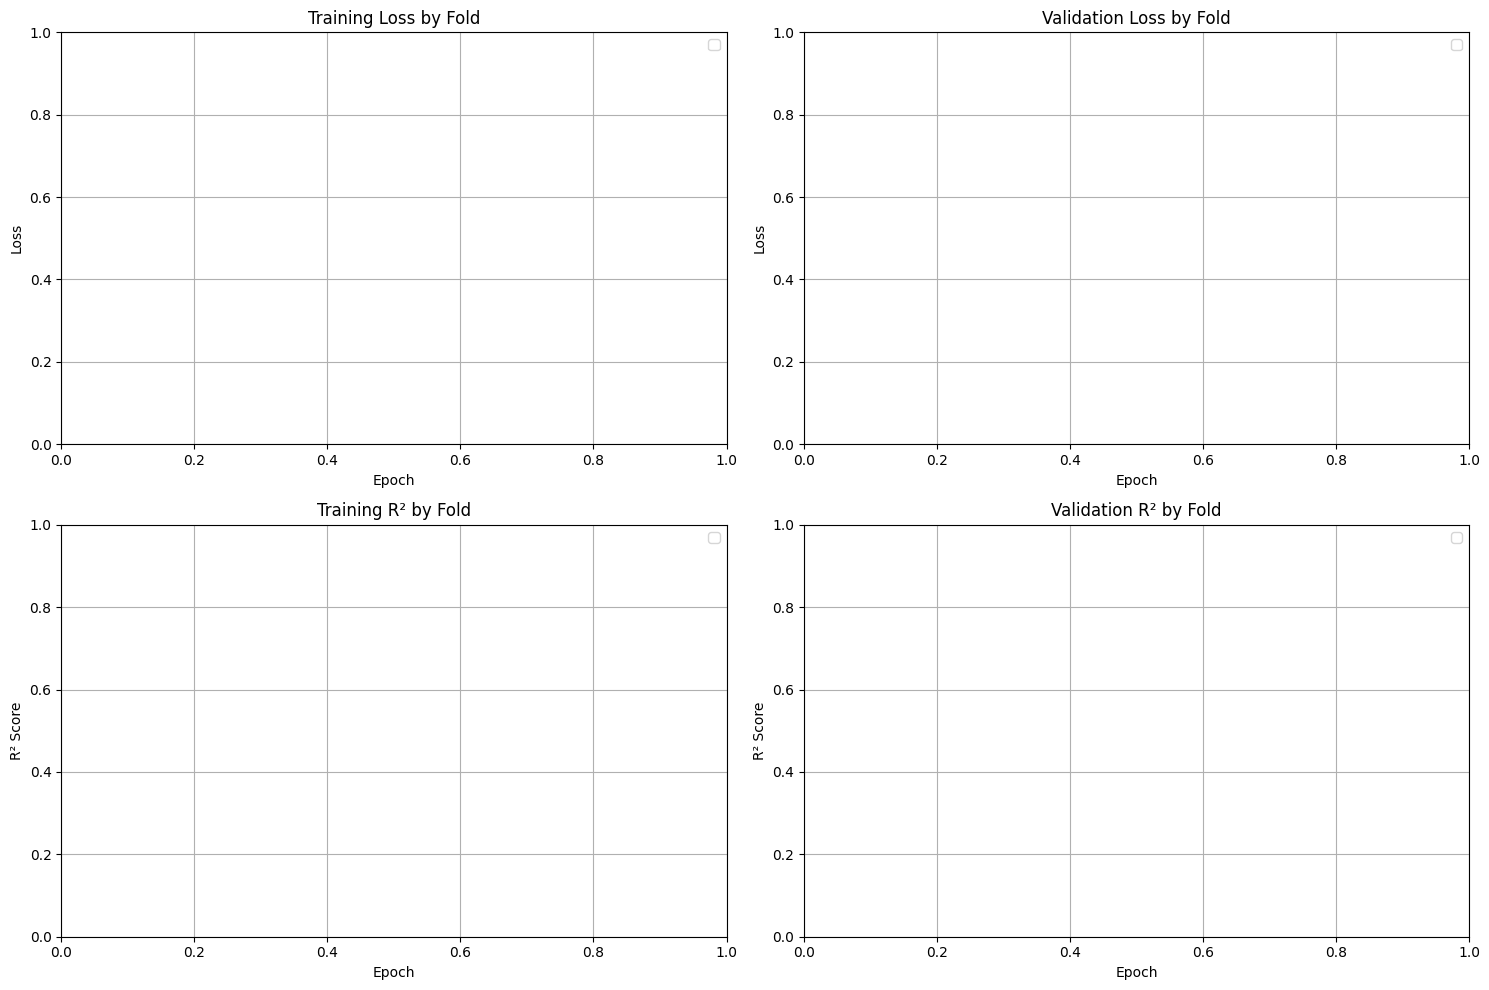


Fold Summary:
------------------------------------------------------------
------------------------------------------------------------


NameError: name 'avg_val_r2' is not defined

In [28]:
# Visualize training history for all folds
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot Loss
for i, result in enumerate(fold_results):
    axes[0, 0].plot(result['train_losses'], alpha=0.6, label=f'Fold {i+1} Train')
    axes[0, 1].plot(result['val_losses'], alpha=0.6, label=f'Fold {i+1} Val')

axes[0, 0].set_title('Training Loss by Fold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].set_title('Validation Loss by Fold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot R2
for i, result in enumerate(fold_results):
    axes[1, 0].plot(result['train_r2'], alpha=0.6, label=f'Fold {i+1} Train')
    axes[1, 1].plot(result['val_r2'], alpha=0.6, label=f'Fold {i+1} Val')

axes[1, 0].set_title('Training R² by Fold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].set_title('Validation R² by Fold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFold Summary:")
print("-" * 60)
for i, result in enumerate(fold_results):
    print(f"Fold {i+1}: Best Val R² = {result['best_val_r2']:.4f}")
print("-" * 60)
print(f"Mean Val R²: {avg_val_r2:.4f}")
print(f"Std Val R²: {np.std([r['best_val_r2'] for r in fold_results]):.4f}")


In [27]:
# Aggregate and plot average metrics across folds (safe, robust)
import matplotlib.pyplot as plt
import numpy as np

if 'fold_results' in globals() and len(fold_results) > 0:
    # Determine max epochs across folds
    max_epochs = max(len(r['train_losses']) for r in fold_results)

    # Build matrices padded to max_epochs
    def pad_list(lst, length):
        if len(lst) >= length:
            return np.array(lst[:length])
        # pad by repeating last value
        return np.concatenate([np.array(lst), np.full(length - len(lst), lst[-1])])

    train_loss_mat = np.stack([pad_list(r['train_losses'], max_epochs) for r in fold_results])
    val_loss_mat   = np.stack([pad_list(r['val_losses'],   max_epochs) for r in fold_results])
    train_r2_mat   = np.stack([pad_list(r['train_r2'],     max_epochs) for r in fold_results])
    val_r2_mat     = np.stack([pad_list(r['val_r2'],       max_epochs) for r in fold_results])

    avg_train_loss = train_loss_mat.mean(axis=0)
    avg_val_loss   = val_loss_mat.mean(axis=0)
    avg_train_r2   = train_r2_mat.mean(axis=0)
    avg_val_r2     = val_r2_mat.mean(axis=0)

    epochs = np.arange(1, max_epochs + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, avg_train_loss, label='Avg Train Loss')
    plt.plot(epochs, avg_val_loss, label='Avg Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Average Loss Across Folds')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, avg_train_r2, label='Avg Train R2')
    plt.plot(epochs, avg_val_r2, label='Avg Val R2')
    plt.xlabel('Epoch')
    plt.ylabel('R²')
    plt.title('Average R² Across Folds')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Mark todo step completed
else:
    print("No `fold_results` found. Run the K-Fold training first (the cell that trains all folds).")
    print("After training, re-run this cell to visualize average metrics.")


No `fold_results` found. Run the K-Fold training first (the cell that trains all folds).
After training, re-run this cell to visualize average metrics.


In [25]:
# Ensemble prediction using all K-fold models
import numpy as np
import torch
import pandas as pd
from tqdm import tqdm

target_cols = [
    "Dry_Green_g",
    "Dry_Dead_g",
    "Dry_Clover_g",
    "GDM_g",
    "Dry_Total_g",
]

test_dataset = Image2BioMassTestDataset(
    dataset_path="/kaggle/input/csiro-biomass/",
    img_transform=val_transform,
)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Collect predictions from all folds
all_fold_predictions = []

for fold_num, result in enumerate(fold_results):
    print(f"Generating predictions with Fold {fold_num + 1} model...")
    
    model = result['model']
    model.eval()
    fold_preds = []
    fold_sample_ids = []
    
    with torch.no_grad():
        for imgs, _, sample_ids in tqdm(test_dataloader, desc=f"Fold {fold_num + 1} Inference"):
            imgs = imgs.to(device)
            
            # Predict without tabular data (test scenario)
            preds3, _ = model(imgs, None, None)
            
            # Reverse log transform
            preds3 = target_untransform(preds3).cpu().numpy()
            
            # Extract predictions
            dg = preds3[:, 0]  # Dry_Green_g
            dd = preds3[:, 1]  # Dry_Dead_g
            dc = preds3[:, 2]  # Dry_Clover_g
            
            # Compute derived targets
            gdm = dg + dc
            dry_total = dg + dd + dc
            
            preds5 = np.stack([dg, dd, dc, gdm, dry_total], axis=1)
            fold_preds.append(preds5)
            fold_sample_ids.extend(sample_ids)
    
    # Concatenate all batches for this fold
    fold_preds = np.concatenate(fold_preds, axis=0)
    all_fold_predictions.append(fold_preds)

# Average predictions across all folds (ensemble)
ensemble_preds = np.mean(all_fold_predictions, axis=0)
print(f"\nEnsemble predictions shape: {ensemble_preds.shape}")

# Build submission
rows = []
for sid, pred_vec in zip(fold_sample_ids, ensemble_preds):
    for col, value in zip(target_cols, pred_vec):
        rows.append({
            "sample_id": f"{sid}__{col}",
            "target": float(value)
        })

df_submit = pd.DataFrame(rows)
df_submit.to_csv("submission_kfold_ensemble.csv", index=False)
print("Saved submission_kfold_ensemble.csv")
print(f"Total predictions: {len(df_submit)}")
df_submit.head(20)



Ensemble predictions shape: ()


/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


NameError: name 'fold_sample_ids' is not defined